First 5 Rows
        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      

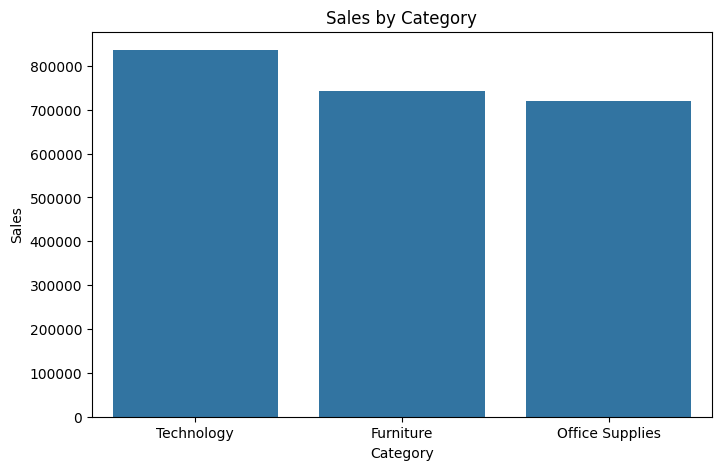

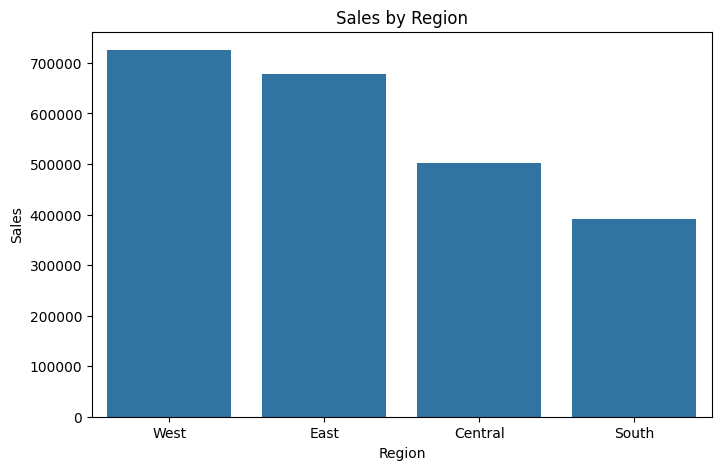

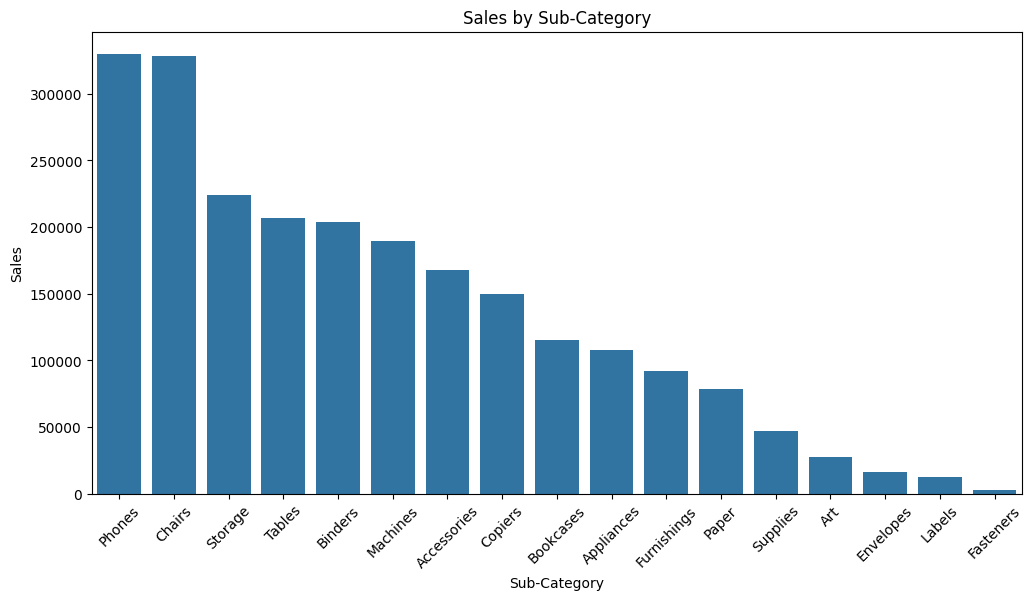

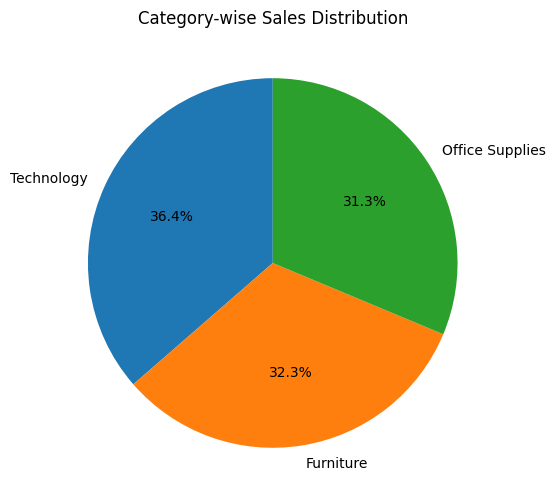

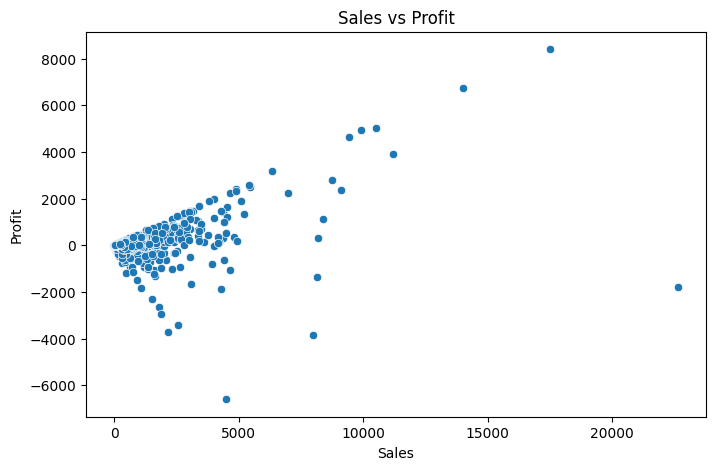

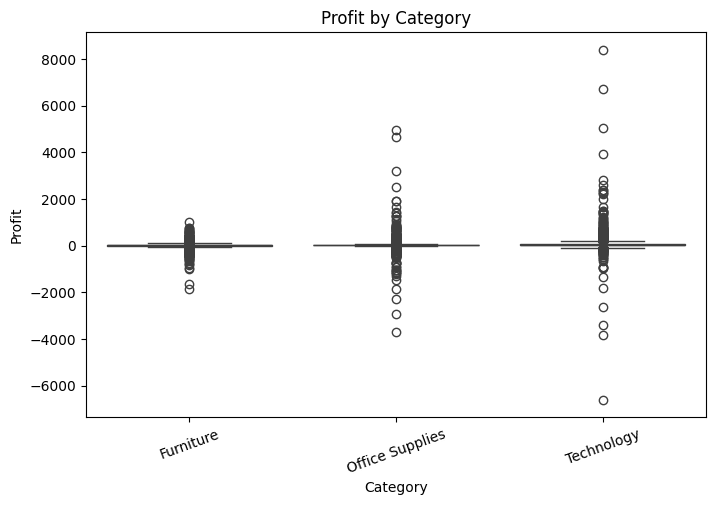

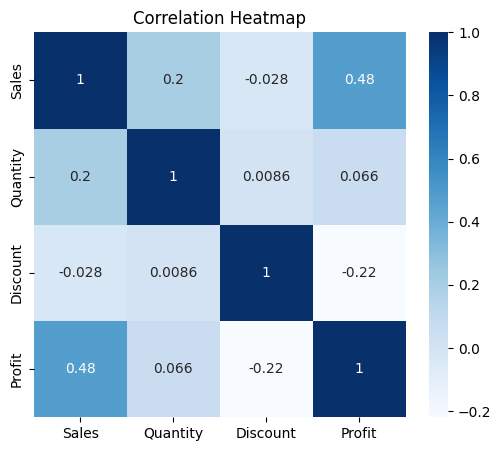


Real-World Retail Shop Data Analysis Report

1. Technology, Furniture, and Office Supplies are the major product categories contributing to overall sales.

2. Sales performance differs across regions, indicating variations in customer demand.

3. Some sub-categories generate significantly higher sales than others, helping identify the best-selling products.

4. The Sales vs Profit analysis shows that higher sales do not always result in higher profits because discounts and product costs affect profitability.

5. The correlation heatmap indicates positive relationships between Sales, Quantity, and Profit, while higher discounts may reduce profit.

Conclusion:
This retail sales analysis provides valuable business insights by identifying high-performing categories, profitable regions, and important relationships between sales, quantity, discounts, and profit. These findings can help improve inventory management, pricing strategies, and business decision-making.



In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_data.csv")

print("First 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

df = df.dropna()

print("\nTotal Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print("\nSales by Category")
print(category_sales)

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print("\nSales by Region")
print(region_sales)

subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print("\nSales by Sub-Category")
print(subcategory_sales)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

plt.figure(figsize=(12,6))
sns.barplot(x=subcategory_sales.index, y=subcategory_sales.values)
plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(6,6))
plt.pie(
    category_sales.values,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Category-wise Sales Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sales", y="Profit")
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Category", y="Profit", data=df)
plt.title("Profit by Category")
plt.xticks(rotation=20)
plt.show()

corr = df[["Sales", "Quantity", "Discount", "Profit"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

print("""
Real-World Retail Shop Data Analysis Report

1. Technology, Furniture, and Office Supplies are the major product categories contributing to overall sales.

2. Sales performance differs across regions, indicating variations in customer demand.

3. Some sub-categories generate significantly higher sales than others, helping identify the best-selling products.

4. The Sales vs Profit analysis shows that higher sales do not always result in higher profits because discounts and product costs affect profitability.

5. The correlation heatmap indicates positive relationships between Sales, Quantity, and Profit, while higher discounts may reduce profit.

Conclusion:
This retail sales analysis provides valuable business insights by identifying high-performing categories, profitable regions, and important relationships between sales, quantity, discounts, and profit. These findings can help improve inventory management, pricing strategies, and business decision-making.
""")